<a href="https://colab.research.google.com/github/vaishnavi-gujare/Dataframe-projects/blob/main/Session_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploded = files.upload()

Saving heart.csv to heart.csv


In [3]:
filepath = '/content/heart.csv'
df = pd.read_csv(filepath)

In [4]:
df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [6]:
df.shape

(918, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [9]:
print(df.isnull().sum())

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [13]:
df.duplicated().sum()

np.int64(0)

In [16]:
cholesterol_zero = (df['Cholesterol'] == 0).sum()
restingbp_zero = (df['RestingBP'] == 0).sum()

print("Rows with 0 Cholesterol:", cholesterol_zero)
print("Rows with 0 RestingBP:", restingbp_zero)

Rows with 0 Cholesterol: 172
Rows with 0 RestingBP: 1


In [17]:
print("Before Cleaning:")
print(df[['Cholesterol', 'RestingBP']].describe())
chol_mean = df.loc[df['Cholesterol'] != 0, 'Cholesterol'].mean()
bp_mean = df.loc[df['RestingBP'] != 0, 'RestingBP'].mean()

df['Cholesterol'] = df['Cholesterol'].replace(0, chol_mean)
df['RestingBP'] = df['RestingBP'].replace(0, bp_mean)

df['Cholesterol'] = df['Cholesterol'].round(2)
df['RestingBP'] = df['RestingBP'].round(2)

print("After Cleaning:")
print(df[['Cholesterol', 'RestingBP']].describe())

Before Cleaning:
       Cholesterol   RestingBP
count   918.000000  918.000000
mean    198.799564  132.396514
std     109.384145   18.514154
min       0.000000    0.000000
25%     173.250000  120.000000
50%     223.000000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000
After Cleaning:
       Cholesterol   RestingBP
count   918.000000  918.000000
mean    244.636253  132.540893
std      53.318029   17.989932
min      85.000000   80.000000
25%     214.000000  120.000000
50%     244.640000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000


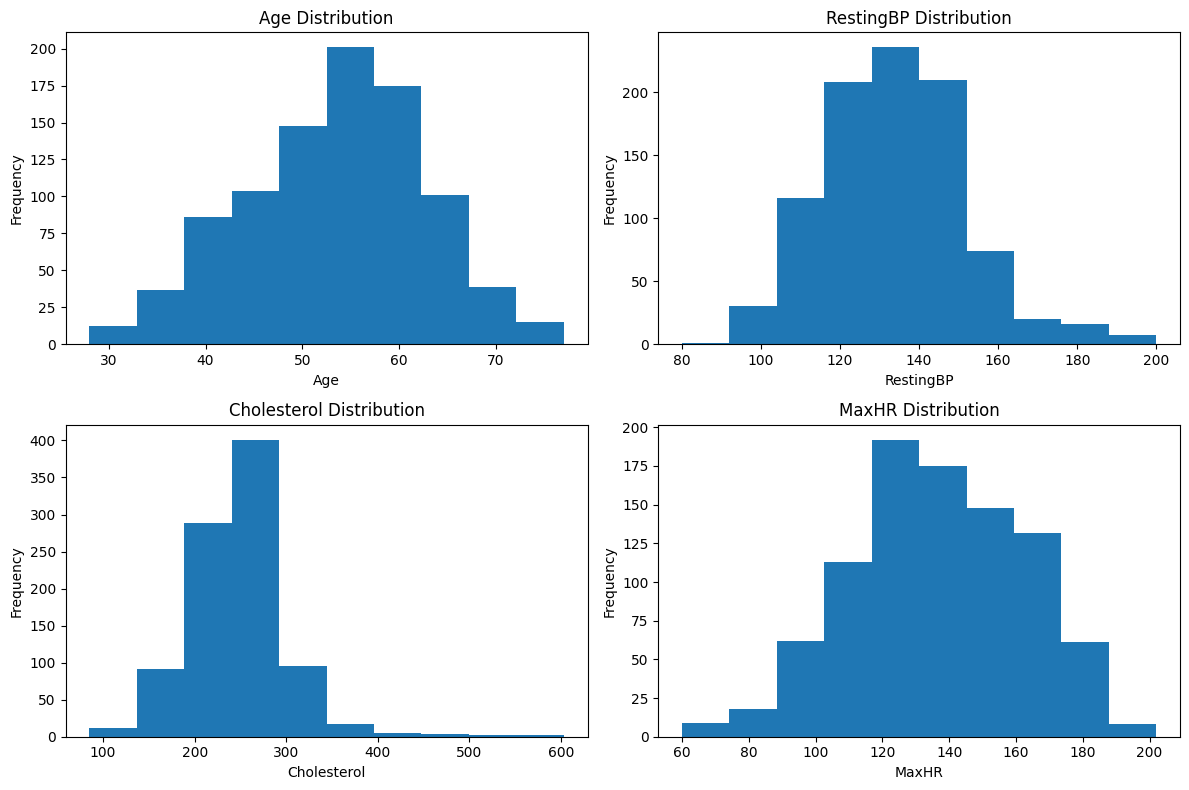

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.hist(df['Age'])
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.subplot(2, 2, 2)
plt.hist(df['RestingBP'])
plt.title('RestingBP Distribution')
plt.xlabel('RestingBP')
plt.ylabel('Frequency')

plt.subplot(2, 2, 3)
plt.hist(df['Cholesterol'])
plt.title('Cholesterol Distribution')
plt.xlabel('Cholesterol')
plt.ylabel('Frequency')

plt.subplot(2, 2, 4)
plt.hist(df['MaxHR'])
plt.title('MaxHR Distribution')
plt.xlabel('MaxHR')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [19]:
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(include='object').columns

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease'],
      dtype='object')
Categorical Columns: Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')


In [20]:
categorical_cols = df.select_dtypes(include='object').columns

df_encoded = pd.get_dummies(df, columns=categorical_cols)
print("Shape of Encoded DataFrame:", df_encoded.shape)

print("First 5 Rows:")
print(df_encoded.head())

Shape of Encoded DataFrame: (918, 21)
First 5 Rows:
   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  \
0   40      140.0        289.0          0    172      0.0             0   
1   49      160.0        180.0          0    156      1.0             1   
2   37      130.0        283.0          0     98      0.0             0   
3   48      138.0        214.0          0    108      1.5             1   
4   54      150.0        195.0          0    122      0.0             0   

   Sex_F  Sex_M  ChestPainType_ASY  ...  ChestPainType_NAP  ChestPainType_TA  \
0  False   True              False  ...              False             False   
1   True  False              False  ...               True             False   
2  False   True              False  ...              False             False   
3   True  False               True  ...              False             False   
4  False   True              False  ...               True             False   

   RestingECG_LV

In [21]:
print("Final Shape:", df_encoded.shape)
print("Column Names:")
print(df_encoded.columns.tolist())

Final Shape: (918, 21)
Column Names:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease', 'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']
